In [ ]:
import tensorflow as tf
mnist=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()

In [ ]:
print("Train images shape:",train_images.shape)
print("Train labels shape:",train_labels.shape)
print("Test images shape:",test_images.shape)
print("Test labels shape:",test_labels.shape)

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


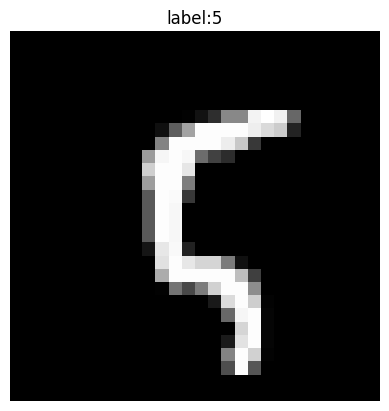

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(train_images[100],cmap="gray")
plt.title(f"label:{train_labels[0]}")
plt.axis("off")
plt.show()

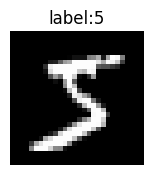

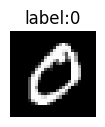

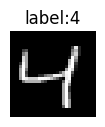

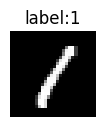

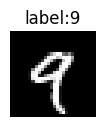

In [ ]:
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(train_images[i],cmap="gray")
  plt.title(f"label:{train_labels[i]}")
  plt.axis("off")
  plt.show()

In [ ]:
train_images=train_images/255.0
test_images=test_images/255.0

In [ ]:
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models
import tensorflow as tf

model=models.Sequential([
    tf.keras.Input(shape=(28,28,1)),
    layers.Conv2D(16,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
test_loss,test_acc=model.evaluate(test_images,test_labels)
print("accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0776 - loss: 2.3480
accuracy: 0.07760000228881836


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
Original Label: 1
Predicted Label: 0


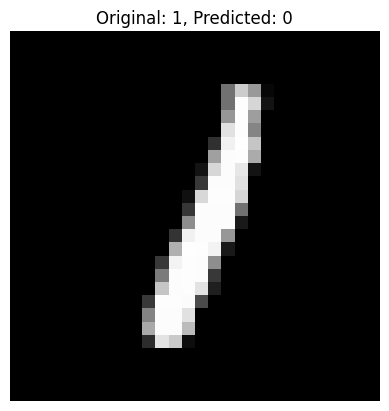

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()